Brain Tumor Classification Using Convolutional Neural Networks

Brain tumors are abnormal growths of cells in the brain and can be difficult to identify accurately through manual examination of MRI scans. The objective of this project is to develop a deep learning-based image classification system that can automatically analyze brain MRI images and classify them into four categories:

Glioma
Meningioma
Pituitary Tumor
No Tumor

A Convolutional Neural Network (CNN) is developed using TensorFlow/Keras to automatically learn important visual features from MRI images. Image preprocessing and data augmentation techniques such as rescaling, rotation, shifting, shearing, zooming, and horizontal flipping are applied to improve the model's ability to generalize to unseen images.

The trained model is evaluated using a separate testing dataset and can subsequently be used to predict the class of a new MRI image along with its predicted confidence.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
DATASET_PATH = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image"

In [3]:
#  Image Data Generators
train_datagen = ImageDataGenerator(
    rescale =1./255,
    rotation_range =20,
    width_shift_range =0.2,
    height_shift_range =0.2,
    shear_range =0.2,
    zoom_range =0.2,
    horizontal_flip = True,
    validation_split=0.1  # 10% of training data for validation
)

#  Training data
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH +"\\Training",
    target_size=(150,150),
    batch_size=32,
    class_mode="categorical",
    subset ="training"
)
#  Validation data
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
#  Test data
test_datagen= ImageDataGenerator(rescale=1./255)
test_generator=test_datagen.flow_from_directory(
    DATASET_PATH + "\\Testing",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 5143 images belonging to 4 classes.
Found 569 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [5]:
#CNN Model
model=Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(512,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes: Glioma, Meningioma, Pituitary, No Tumor
])
#compile
model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.fit(train_generator, validation_data=val_generator, epochs=40)

Epoch 1/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.5063 - loss: 1.0779 - val_accuracy: 0.5817 - val_loss: 0.9929
Epoch 2/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 116s 717ms/step - accuracy: 0.6644 - loss: 0.8160 - val_accuracy: 0.6678 - val_loss: 0.8408
Epoch 3/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 93s 574ms/step - accuracy: 0.7198 - loss: 0.7002 - val_accuracy: 0.6239 - val_loss: 0.8547
Epoch 4/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 86s 536ms/step - accuracy: 0.7527 - loss: 0.6214 - val_accuracy: 0.6889 - val_loss: 0.8007
Epoch 5/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 89s 554ms/step - accuracy: 0.7560 - loss: 0.6123 - val_accuracy: 0.7381 - val_loss: 0.7233
Epoch 6/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 97s 601ms/step - accuracy: 0.7873 - loss: 0.5373 - val_accuracy: 0.7698 - val_loss: 0.6716
Epoch 7/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 88s 544ms/step - accuracy: 0.7984 - loss: 0.5113 - val_accuracy: 0.6643 - val_loss: 0.8647
Epoch 8/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 89s 553ms/step - accuracy: 0.8149 - loss: 0.

In [7]:
img_path = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image\glioma_exmp.jpg"

In [ ]:
#img_path = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image\meningloma.jpg"

In [ ]:
#mg_path = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image\no_tumer.jpg"

In [ ]:
#img_path = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image\pitutary_2.jpg"

In [ ]:
#img_path = r"C:\Users\bavin\OneDrive\Desktop\Brain Tumor Project\data image\pitutary_exmp.jpg"

In [8]:
class_labels = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step

Predicted Class: Glioma
Confidence: 99.60%


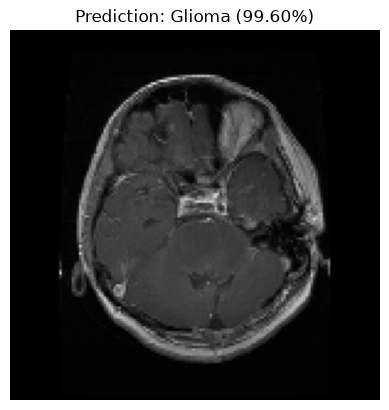

In [9]:
# Load and preprocess image

img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

#Predict

prediction=model.predict(img_array)
predicted_index=np.argmax(prediction,axis=1)[0]
predicted_label=class_labels[predicted_index]
confidence = np.max(prediction) * 100

print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")


plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

Conclusion

The deep learning-based CNN model successfully classified brain MRI images into four categories: Glioma, Meningioma, Pituitary Tumor, and No Tumor. By using image preprocessing and data augmentation techniques, the model achieved an accuracy of 94.59%, demonstrating strong performance in identifying different brain tumor categories from MRI images.

Overall, the project demonstrates the potential of deep learning in medical image classification and can serve as a useful decision-support tool for preliminary analysis. However, the model should not replace professional medical diagnosis, and further improvement can be achieved through larger datasets, transfer learning, and more comprehensive evaluation metrics such as precision, recall, F1-score, and confusion matrix.